In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [2]:
columns = ['mean_profile', 'std_profile', 'kurtosis_profile', 'skewness_profile',
           'mean_dmsnr', 'std_dmsnr', 'kurtosis_dmsnr', 'skewness_dmsnr', 'target']
df = pd.read_csv('HTRU_2.csv', header=None, names=columns)
df

,mean_profile,std_profile,kurtosis_profile,skewness_profile,mean_dmsnr,std_dmsnr,kurtosis_dmsnr,skewness_dmsnr,target
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,0
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0
...,...,...,...,...,...,...,...,...,...
17893,136.429688,59.847421,-0.187846,-0.738123,1.296823,12.166062,15.450260,285.931022,0
17894,122.554688,49.485605,0.127978,0.323061,16.409699,44.626893,2.945244,8.297092,0
17895,119.335938,59.935939,0.159363,-0.743025,21.430602,58.872000,2.499517,4.595173,0
17896,114.507812,53.902400,0.201161,-0.024789,1.946488,13.381731,10.007967,134.238910,0


In [3]:
df.head(20)

,mean_profile,std_profile,kurtosis_profile,skewness_profile,mean_dmsnr,std_dmsnr,kurtosis_dmsnr,skewness_dmsnr,target
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,0
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0
5,93.570312,46.698114,0.531905,0.416721,1.636288,14.545074,10.621748,131.394004,0
6,119.484375,48.765059,0.031460,-0.112168,0.999164,9.279612,19.206230,479.756567,0
7,130.382812,39.844056,-0.158323,0.389540,1.220736,14.378941,13.539456,198.236457,0
8,107.250000,52.627078,0.452688,0.170347,2.331940,14.486853,9.001004,107.972506,0
9,107.257812,39.496488,0.465882,1.162877,4.079431,24.980418,7.397080,57.784738,0


In [4]:
df.tail(20)

,mean_profile,std_profile,kurtosis_profile,skewness_profile,mean_dmsnr,std_dmsnr,kurtosis_dmsnr,skewness_dmsnr,target
17878,90.148438,40.786044,0.457139,0.885516,5.354515,29.759511,6.102231,37.979520,0
17879,107.664062,44.462463,0.296046,0.227765,6.290970,33.512873,5.536014,30.245117,0
17880,105.492188,43.500718,0.154180,0.408117,2.316054,19.098507,9.377229,95.200946,0
17881,130.500000,46.149553,0.084445,-0.107355,1.529264,11.757086,12.533831,211.327081,0
17882,131.000000,55.935789,-0.023598,-0.536651,1.159699,10.856794,15.019974,289.362790,0
17883,84.421875,41.775555,0.757467,1.107075,1.336120,12.026757,14.502863,258.119819,0
17884,106.875000,47.571328,0.199440,0.284964,3.079431,20.984455,8.427475,78.259366,0
17885,133.820312,43.478161,0.136691,0.353121,0.982441,9.486068,18.528395,444.411748,0
17886,127.070312,47.663564,0.006552,-0.123634,0.853679,11.197206,16.122702,296.507738,0
17887,121.375000,53.245158,0.103772,-0.365119,1.095318,12.239976,16.258042,303.880023,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17898 entries, 0 to 17897
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   mean_profile      17898 non-null  float64
 1   std_profile       17898 non-null  float64
 2   kurtosis_profile  17898 non-null  float64
 3   skewness_profile  17898 non-null  float64
 4   mean_dmsnr        17898 non-null  float64
 5   std_dmsnr         17898 non-null  float64
 6   kurtosis_dmsnr    17898 non-null  float64
 7   skewness_dmsnr    17898 non-null  float64
 8   target            17898 non-null  int64  
dtypes: float64(8), int64(1)
memory usage: 1.2 MB


In [6]:
df.shape

(17898, 9)

In [7]:
df.dtypes

mean_profile        float64
std_profile         float64
kurtosis_profile    float64
skewness_profile    float64
mean_dmsnr          float64
std_dmsnr           float64
kurtosis_dmsnr      float64
skewness_dmsnr      float64
target                int64
dtype: object

In [8]:
df.describe()

,mean_profile,std_profile,kurtosis_profile,skewness_profile,mean_dmsnr,std_dmsnr,kurtosis_dmsnr,skewness_dmsnr,target
count,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000
mean,111.079968,46.549532,0.477857,1.770279,12.614400,26.326515,8.303556,104.857709,0.091574
std,25.652935,6.843189,1.064040,6.167913,29.472897,19.470572,4.506092,106.514540,0.288432
min,5.812500,24.772042,-1.876011,-1.791886,0.213211,7.370432,-3.139270,-1.976976,0.000000
25%,100.929688,42.376018,0.027098,-0.188572,1.923077,14.437332,5.781506,34.960504,0.000000
50%,115.078125,46.947479,0.223240,0.198710,2.801839,18.461316,8.433515,83.064556,0.000000
75%,127.085938,51.023202,0.473325,0.927783,5.464256,28.428104,10.702959,139.309330,0.000000
max,192.617188,98.778911,8.069522,68.101622,223.392141,110.642211,34.539844,1191.000837,1.000000


In [9]:
df.value_counts()

mean_profile  std_profile  kurtosis_profile  skewness_profile  mean_dmsnr  std_dmsnr  kurtosis_dmsnr  skewness_dmsnr  target
140.562500    55.683782    -0.234571         -0.699648         3.199833    19.110426   7.975532       74.242225       0         1
102.507812    58.882430     0.465318         -0.515088         1.677258    14.860146   10.576487      127.393580      0         1
103.015625    39.341649     0.323328          1.051164         3.121237    21.744669   7.735822       63.171909       0         1
136.750000    57.178449    -0.068415         -0.636238         3.642977    20.959280   6.896499       53.593661       0         1
88.726562     40.672225     0.600866          1.123492         1.178930    11.468720   14.269573      252.567306      0         1
                                                                                                                               ..
136.429688    59.847421    -0.187846         -0.738123         1.296823    12.166062   15.45026

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.isnull().sum()

mean_profile        0
std_profile         0
kurtosis_profile    0
skewness_profile    0
mean_dmsnr          0
std_dmsnr           0
kurtosis_dmsnr      0
skewness_dmsnr      0
target              0
dtype: int64

In [12]:
df['target'].value_counts()

target
0    16259
1     1639
Name: count, dtype: int64

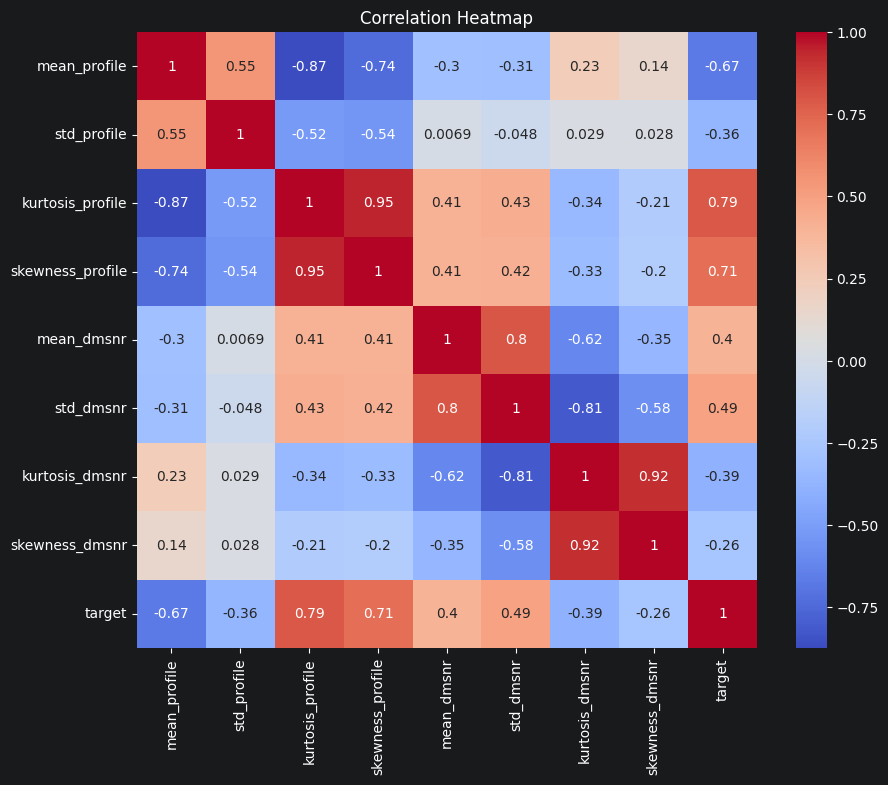

In [13]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

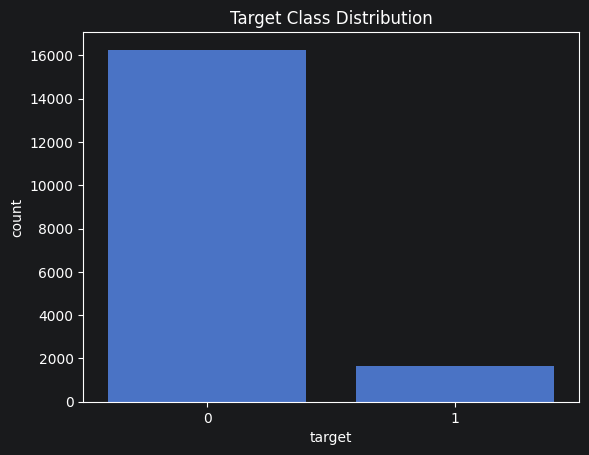

In [14]:
sns.countplot(x='target', data=df)

plt.title("Target Class Distribution")
plt.show()

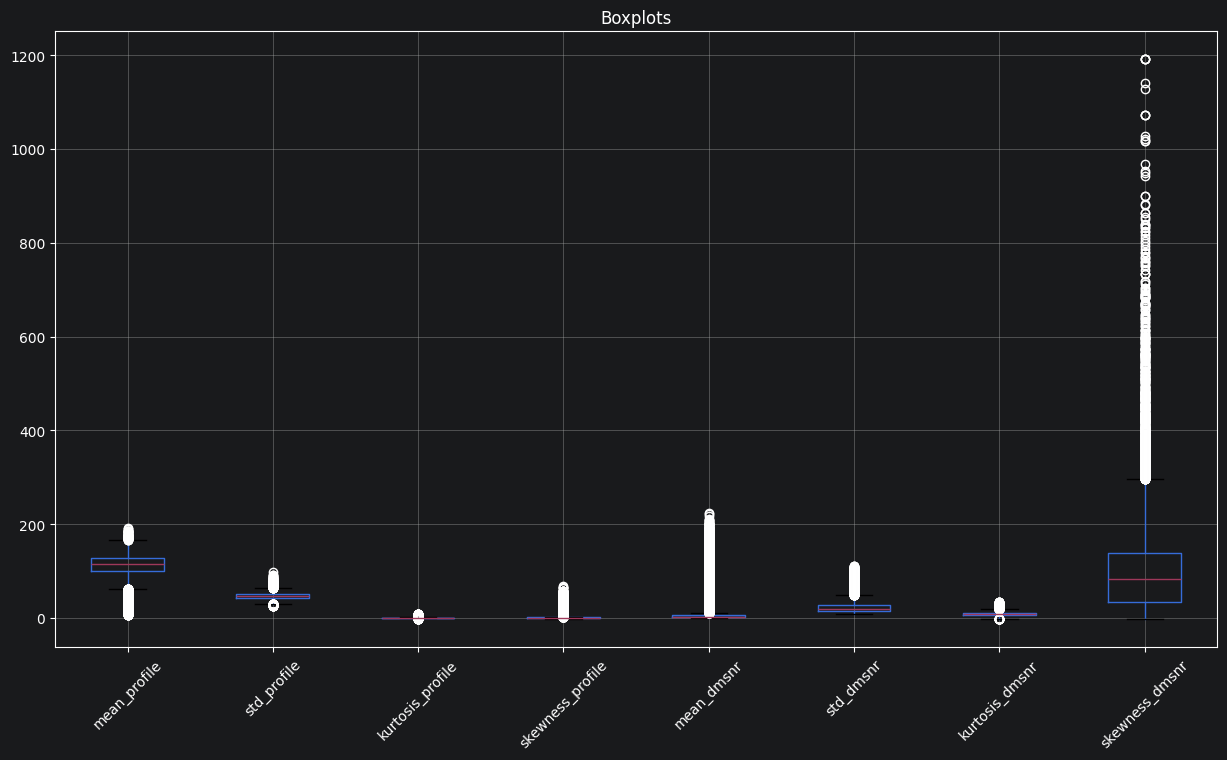

In [15]:
plt.figure(figsize=(15,8))

df.drop('target', axis=1).boxplot()

plt.xticks(rotation=45)
plt.title("Boxplots")
plt.show()

In [16]:
x = df.drop('target',axis = 1)
y = df['target']

In [17]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [18]:
print(f"""{x_train.shape},
        {x_test.shape},
        {y_train.shape},
        {y_test.shape}""")

(14318, 8),
        (3580, 8),
        (14318,),
        (3580,)


In [19]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
print(f"{x_train_scaled.shape},"
      f"{x_test_scaled.shape}")

(14318, 8),(3580, 8)


In [20]:
model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
model.fit(x_train_scaled,y_train)
y_pred = model.predict(x_test_scaled)
y_pred

array([0, 1, 0, ..., 0, 1, 1], shape=(3580,))

In [21]:
y_prob = model.predict_proba(x_test_scaled)[:,1]

In [22]:
y_prob

array([0.04622686, 0.96808396, 0.13417674, ..., 0.04597406, 0.55796243,
       0.99979397], shape=(3580,))

In [23]:
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test,y_pred)
print("Accuracy:", accuracy)
print("report:", report)

Accuracy: 0.9689944134078212
report:               precision    recall  f1-score   support

           0       0.99      0.97      0.98      3259
           1       0.78      0.92      0.84       321

    accuracy                           0.97      3580
   macro avg       0.88      0.95      0.91      3580
weighted avg       0.97      0.97      0.97      3580



In [24]:
model.score(x_train_scaled,y_train)

0.9676630814359547

In [25]:
model.score(x_test_scaled,y_test)

0.9689944134078212

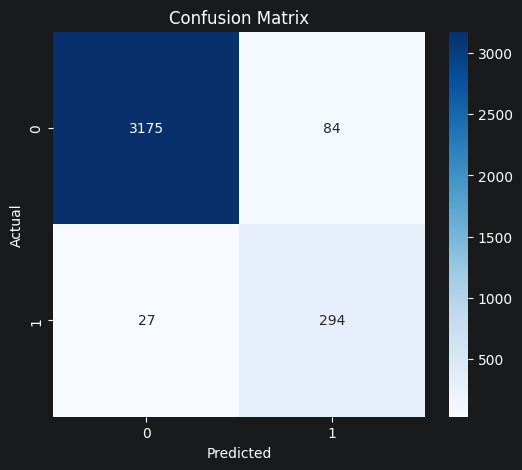

In [26]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [27]:
from sklearn.metrics import roc_auc_score,roc_curve
auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", auc)

ROC-AUC Score: 0.9742491198588332


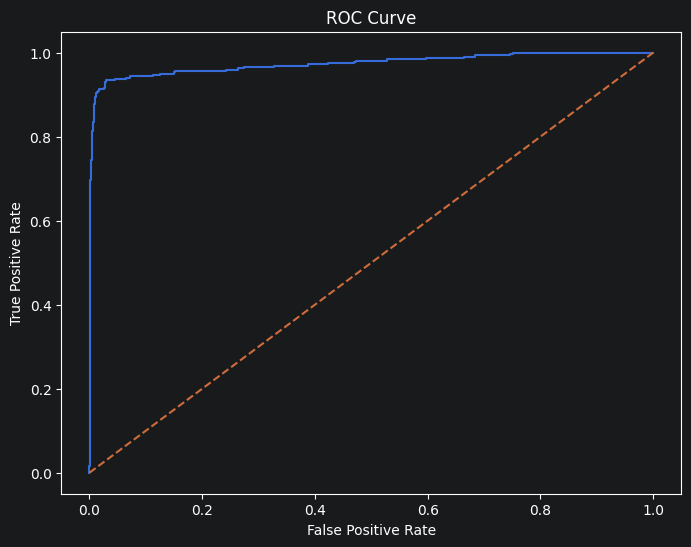

In [28]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

In [29]:
import joblib

joblib.dump(model, "logistic_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']